In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import io

In [21]:
# fetch nifty 500 constitutents from wikipedia along with their sectors

url = 'https://en.wikipedia.org/wiki/NIFTY_500'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

nifty500_df = tables[4]

In [22]:
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)


In [23]:
display(nifty500_df['Industry'].value_counts())

,count
Industry,
Financial Services,92
Capital Goods,61
Healthcare,46
Chemicals,34
Automobile and Auto Components,33
Fast Moving Consumer Goods,31
Information Technology,25
Consumer Durables,25
Consumer Services,25


In [24]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
ticker_list = tickers.tolist()

In [25]:
# get raw OHLC data from yfinance

raw_data = yf.download(ticker_list, period='5y', interval='1wk')

/tmp/ipykernel_32295/2436098472.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_list, period='5y', interval='1wk')
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['SUVENPHAR.NS', 'ISEC.NS', 'GMRINFRASTRUCT.NS', 'PEL.NS', 'TATAMOTORS.NS', 'SWANENERGY.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [26]:
nifty500_index = yf.download('^CRSLDX', period='5y', interval='1wk')

/tmp/ipykernel_32295/3491543142.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty500_index = yf.download('^CRSLDX', period='5y', interval='1wk')
[*********************100%***********************]  1 of 1 completed


In [27]:
closing_prices = raw_data['Close']
benchmark = nifty500_index['Close']

In [28]:
closing_prices = closing_prices.dropna(axis=1)

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(closing_prices, benchmark, test_size=0.2, shuffle=False)

In [30]:
log_returns = np.log(X_train/X_train.shift(1)).dropna()

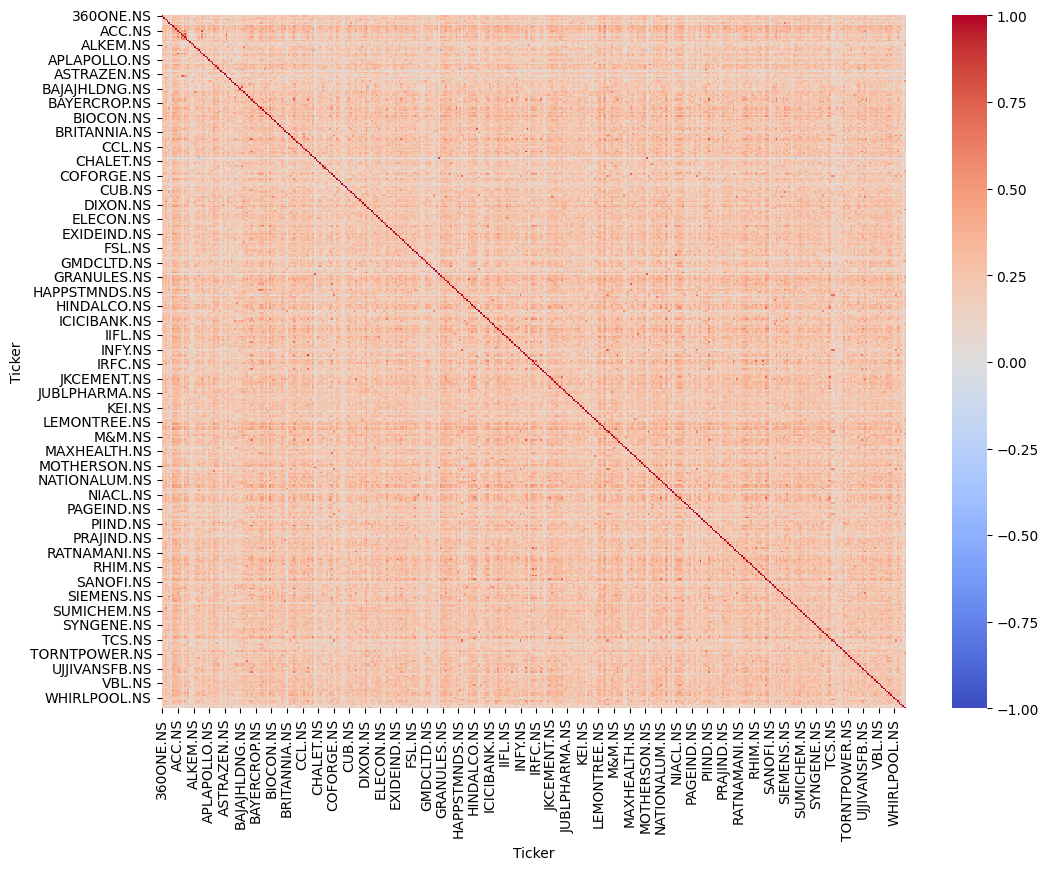

In [32]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [33]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [34]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([107.51081622,  13.81254789,   9.22662006,   7.78774979,
         7.18890336,   6.1947751 ,   5.8653842 ,   5.3515188 ,
         5.15171471,   4.94783224])

array([0.2488173 , 0.03196702, 0.0213536 , 0.01802355, 0.01663761,
       0.01433686, 0.01357453, 0.01238527, 0.01192285, 0.011451  ])

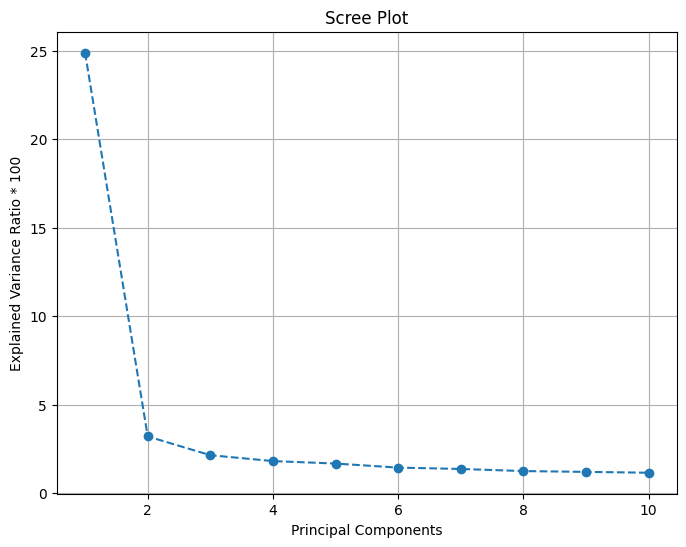

In [35]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [38]:
industry_map = (
    nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry']
)

In [39]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
256,LTF.NS,7.157527,Financial Services
118,DLF.NS,7.056281,Realty
291,NBCC.NS,6.748863,Construction
62,BHEL.NS,6.727284,Capital Goods
350,SAMMAANCAP.NS,6.648775,Financial Services
385,TATAPOWER.NS,6.646515,Power
163,GRAPHITE.NS,6.641997,Capital Goods
253,LICHSGFIN.NS,6.620627,Financial Services
6,ABCAPITAL.NS,6.579862,Financial Services
337,RCF.NS,6.575462,Chemicals


,Ticker,Weight,Industry
17,AJANTPHARM.NS,2.619005,Healthcare
293,NESTLEIND.NS,2.591008,Fast Moving Consumer Goods
72,BRITANNIA.NS,2.300802,Fast Moving Consumer Goods
5,ABBOTINDIA.NS,2.274436,Healthcare
150,GLAND.NS,2.263637,Healthcare
160,GPIL.NS,2.190181,Capital Goods
280,MOTILALOFS.NS,2.126488,Financial Services
34,ASTERDM.NS,1.913948,Healthcare
428,ZFCVINDIA.NS,1.718952,Automobile and Auto Components
88,CGCL.NS,0.966002,Financial Services


In [40]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
183,HINDUNILVR.NS,13.575391,Fast Moving Consumer Goods
207,INFY.NS,12.132581,Information Technology
111,DABUR.NS,12.097279,Fast Moving Consumer Goods
33,ASIANPAINT.NS,11.720994,Consumer Durables
293,NESTLEIND.NS,11.567426,Fast Moving Consumer Goods
289,NAUKRI.NS,10.872382,Consumer Services
46,BAJFINANCE.NS,10.559969,Financial Services
314,PIDILITIND.NS,10.476498,Chemicals
257,LTIM.NS,10.393266,Information Technology
250,LALPATHLAB.NS,10.134886,Healthcare


,Ticker,Weight,Industry
316,PNB.NS,-9.092427,Financial Services
188,HUDCO.NS,-9.115848,Financial Services
283,MRPL.NS,-9.171162,Oil Gas & Consumable Fuels
361,SJVN.NS,-9.467662,Power
214,IRCON.NS,-9.676965,Construction
84,CENTRALBK.NS,-9.853818,Financial Services
52,BANKINDIA.NS,-10.063798,Financial Services
210,IOB.NS,-10.441805,Financial Services
407,UNIONBANK.NS,-10.769326,Financial Services
263,MAHABANK.NS,-11.795652,Financial Services


In [41]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
268,MARUTI.NS,13.582365,Automobile and Auto Components
355,SBIN.NS,13.486830,Financial Services
189,ICICIBANK.NS,12.845089,Financial Services
245,KOTAKBANK.NS,12.584580,Financial Services
42,AXISBANK.NS,11.632674,Financial Services
293,NESTLEIND.NS,10.745940,Fast Moving Consumer Goods
52,BANKINDIA.NS,10.594142,Financial Services
175,HDFCBANK.NS,10.582111,Financial Services
202,INDIANB.NS,10.483967,Financial Services
51,BANKBARODA.NS,10.255957,Financial Services


,Ticker,Weight,Industry
424,WIPRO.NS,-9.210568,Information Technology
257,LTIM.NS,-9.214996,Information Technology
269,MASTEK.NS,-9.594912,Information Technology
122,ECLERX.NS,-10.004410,Services
281,MPHASIS.NS,-11.153062,Information Technology
74,BSOFT.NS,-11.377485,Information Technology
173,HCLTECH.NS,-11.396879,Information Technology
388,TECHM.NS,-11.903292,Information Technology
99,COFORGE.NS,-12.072320,Information Technology
309,PERSISTENT.NS,-12.689451,Information Technology


In [42]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
257,LTIM.NS,15.420287,Information Technology
388,TECHM.NS,13.467442,Information Technology
207,INFY.NS,13.153827,Information Technology
424,WIPRO.NS,12.761799,Information Technology
44,BAJAJFINSV.NS,12.548677,Financial Services
309,PERSISTENT.NS,11.760914,Information Technology
189,ICICIBANK.NS,11.093833,Financial Services
180,HINDALCO.NS,10.992393,Metals & Mining
281,MPHASIS.NS,10.756687,Information Technology
387,TCS.NS,10.660636,Information Technology


,Ticker,Weight,Industry
100,COLPAL.NS,-10.753262,Fast Moving Consumer Goods
17,AJANTPHARM.NS,-10.836013,Healthcare
128,EMAMILTD.NS,-10.873351,Fast Moving Consumer Goods
237,JYOTHYLAB.NS,-11.569394,Fast Moving Consumer Goods
120,DRREDDY.NS,-11.572046,Healthcare
28,APLLTD.NS,-11.684483,Healthcare
157,GODREJCP.NS,-12.386002,Fast Moving Consumer Goods
395,TORNTPHARM.NS,-12.692169,Healthcare
96,CIPLA.NS,-13.449357,Healthcare
429,ZYDUSLIFE.NS,-14.674106,Healthcare


### Performance Measurement

In [43]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" 🎯 STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 🎯 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),10.86%,7.68%
Volatility,18.09%,14.61%
Sharpe Ratio,0.27,0.12
Sortino Ratio,0.46,0.19
Max Drawdown,-13.23%,-13.12%
Calmar Ratio,0.82,0.59
Beta,1.16,1.00
Jensen's Alpha,2.91%,0.00%


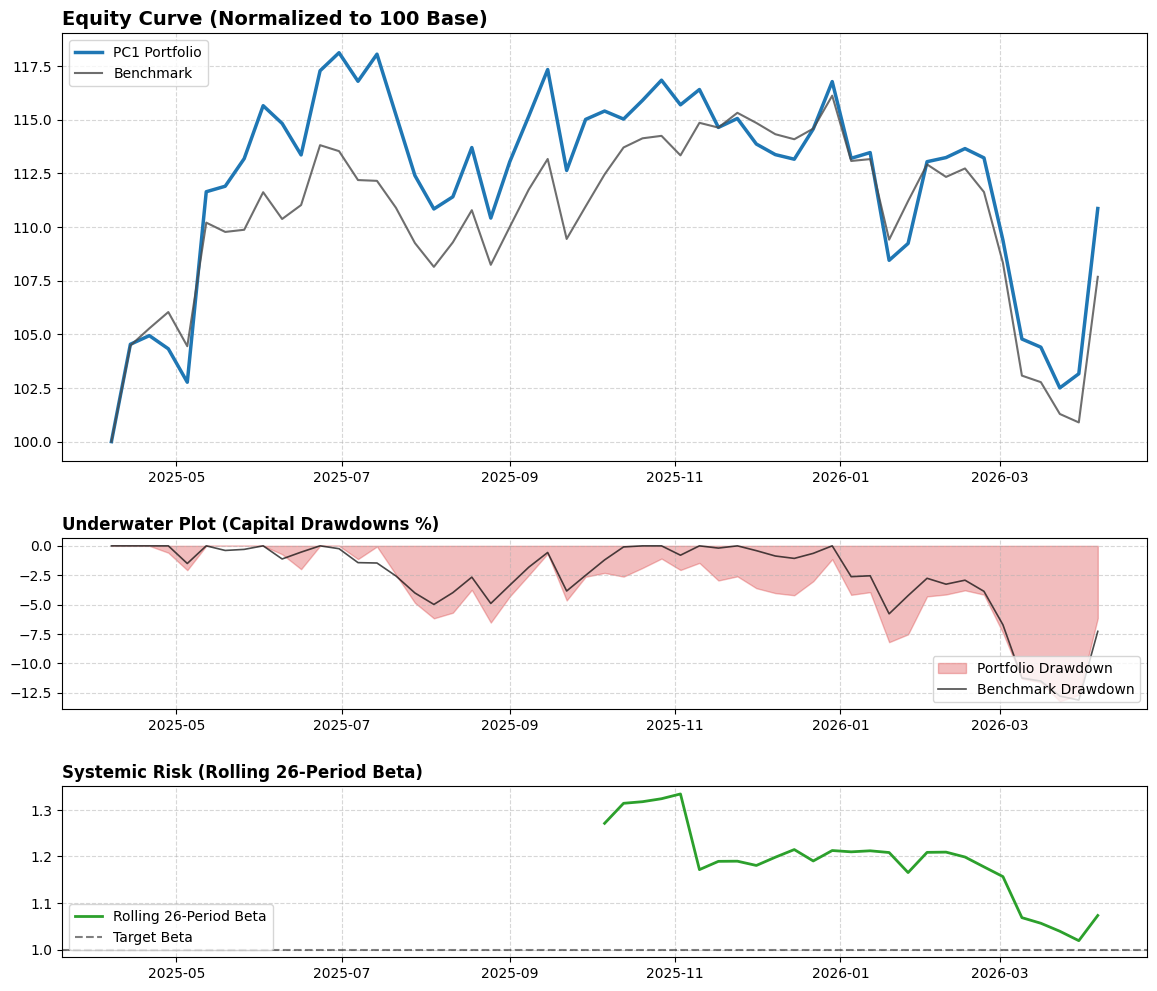

In [44]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=X_test, benchmark_data=Y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-16.62%,7.68%
Volatility,14.90%,14.61%
Sharpe Ratio,-1.52,0.12
Sortino Ratio,-1.89,0.19
Max Drawdown,-18.89%,-13.12%
Calmar Ratio,-0.88,0.59
Beta,-0.54,1.00
Jensen's Alpha,-21.71%,0.00%


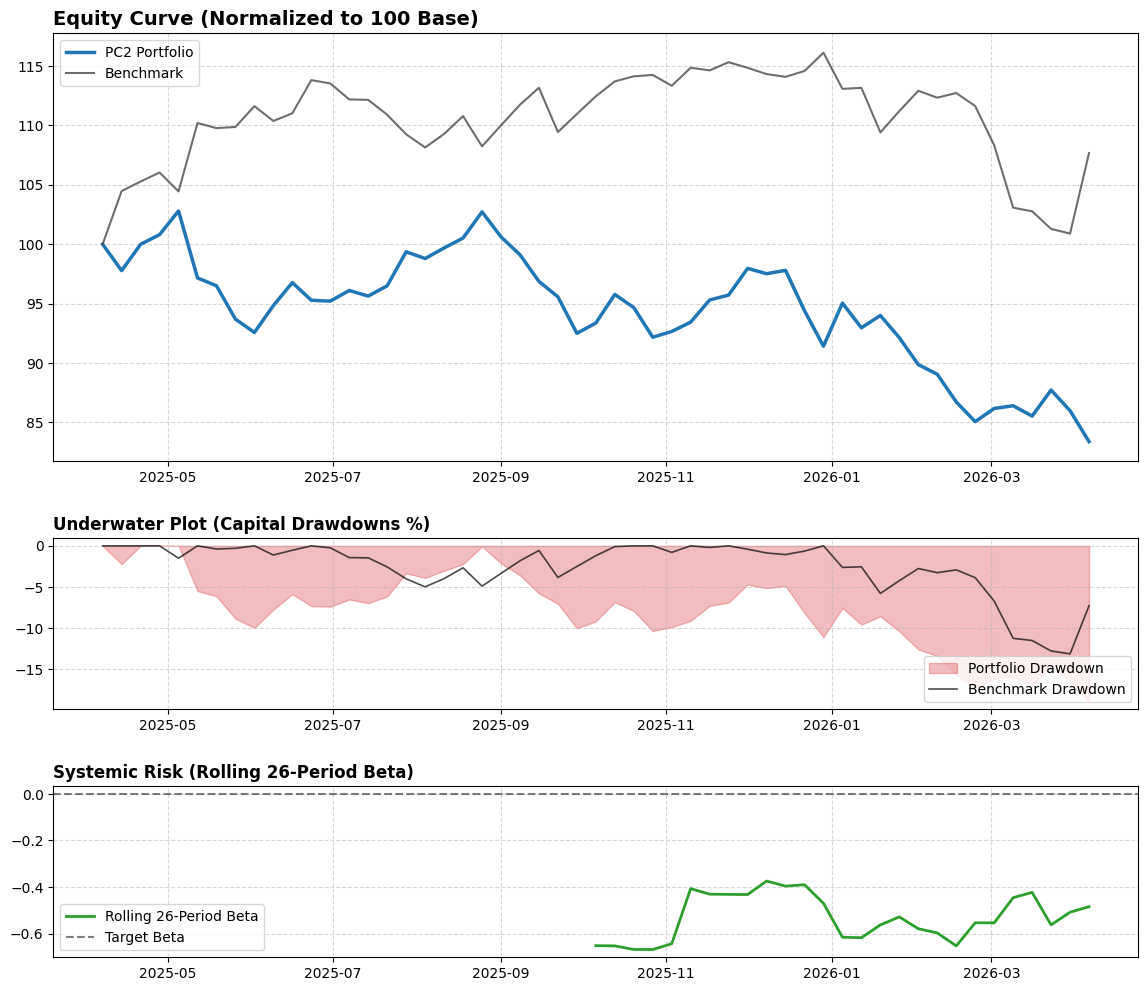

In [46]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=X_test, benchmark_data=Y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),1.54%,7.68%
Volatility,10.10%,14.61%
Sharpe Ratio,-0.44,0.12
Sortino Ratio,-0.63,0.19
Max Drawdown,-9.60%,-13.12%
Calmar Ratio,0.16,0.59
Beta,0.12,1.00
Jensen's Alpha,-4.67%,0.00%


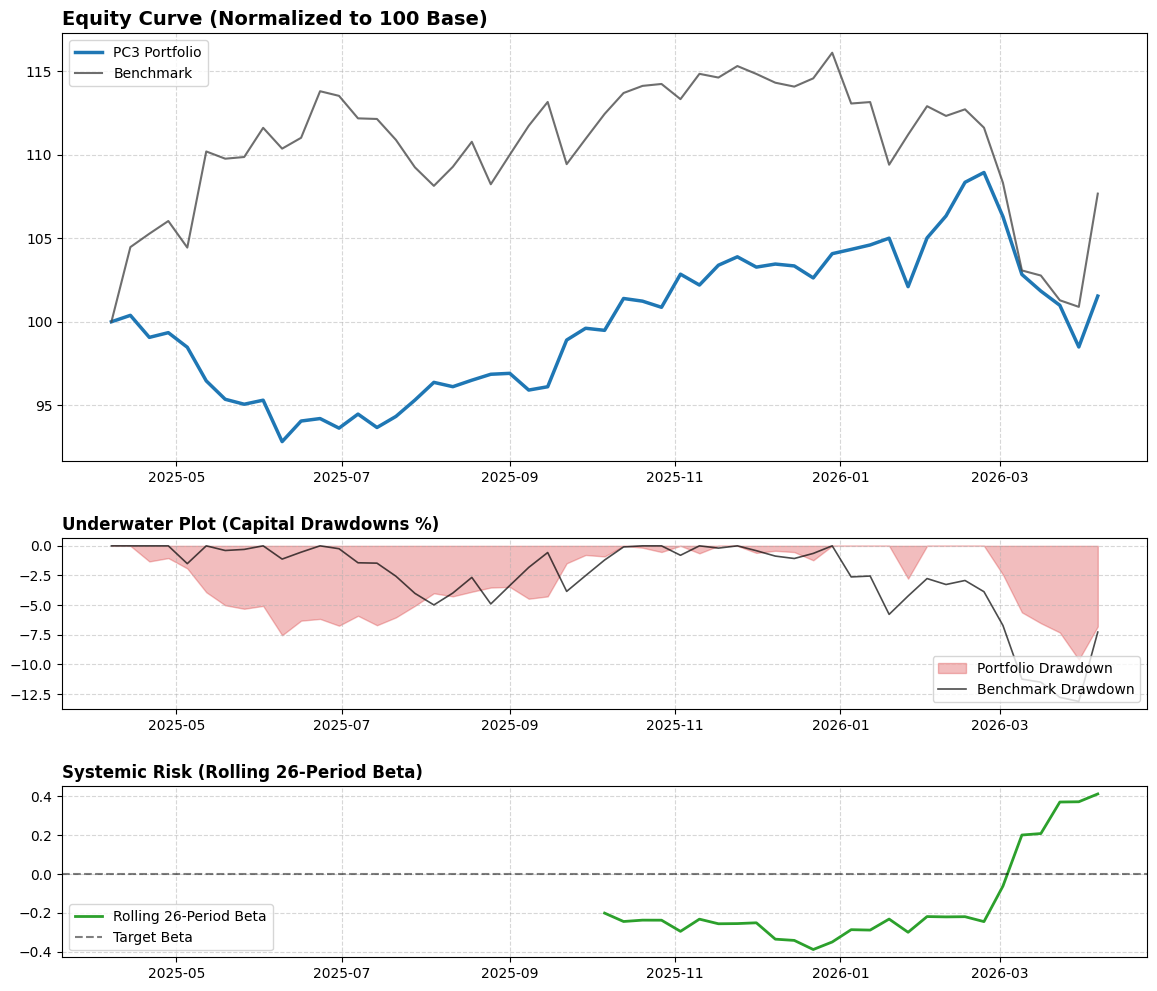

In [48]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=X_test, benchmark_data=Y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),14.80%,7.68%
Volatility,6.92%,14.61%
Sharpe Ratio,1.27,0.12
Sortino Ratio,2.15,0.19
Max Drawdown,-7.32%,-13.12%
Calmar Ratio,2.02,0.59
Beta,0.19,1.00
Jensen's Alpha,8.48%,0.00%


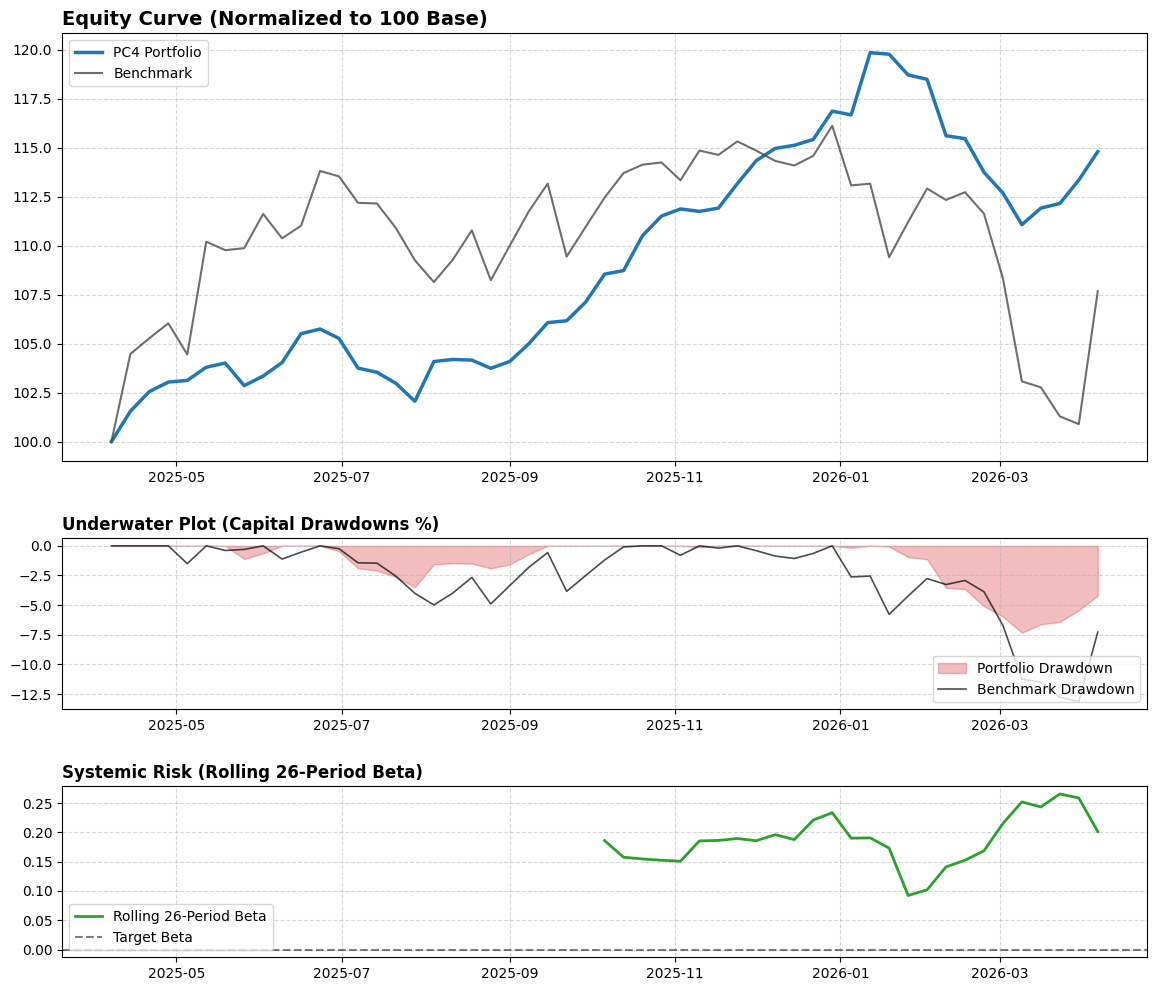

In [50]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=X_test, benchmark_data=Y_test, periods_per_yr=52)